In [ ]:
import networkx as nx
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import random
import itertools
import os
import pickle
from datetime import datetime
# 细胞类型，模拟的身体
CELL_TYPES = ['MuSC', 'Myoblast', 'Myofiber']
color_map = {
        'MuSC': 'blue',
        'Myoblast': 'orange',
        'Myofiber': 'green'
}
# 节点优先级
NODE_NUMER = {
    'MuSC': 1,
    'Myoblast': 2,
    'Myofiber': 3,
}
# 键的方向指向：优先级小的指向优先级大的，然后最后端指向初始的细胞。


In [2]:
def generate_random_planar_cell_graph(
    num_nodes: int,
    max_extra_edges: int = 15,
    seed: int = None
):
    """
    生成带细胞类型的随机平面图（连通、有环、平面）
    :param num_nodes: 节点数量（建议 20~70）
    :param max_extra_edges: 在树基础上最多加多少条边
    :param seed: 随机种子（可选）
    :return: networkx.Graph，每个节点有 'cell_type' 属性
    """
    if seed is not None:
        random.seed(seed)
        # 注意：nx.random_tree 也受全局 random 影响

    # Step 1: 生成随机树（天然平面、连通）
    G = nx.random_tree(num_nodes, seed=seed)

    # Step 2: 为每个节点分配细胞类型
    type_weights = [0.5, 0.3, 0.2]  # 可调整
    cell_assignments = random.choices(CELL_TYPES, weights=type_weights, k=num_nodes)
    for i, cell_type in enumerate(cell_assignments):
        G.nodes[i]['cell_type'] = cell_type
        G.nodes[i]['cell_weight'] = NODE_NUMER[cell_type]

    # Step 3: 预计算所有非边（避免重复尝试）
    all_non_edges = list(itertools.combinations(G.nodes(), 2))
    non_edges = [e for e in all_non_edges if not G.has_edge(*e)]
    random.shuffle(non_edges)

    # Step 4: 尝试添加边，保持平面性
    added_edges = 0
    for u, v in non_edges:
        if added_edges >= max_extra_edges:
            break
        # 临时加边测试
        G_test = G.copy()
        G_test.add_edge(u, v)
        if nx.check_planarity(G_test)[0]:
            G.add_edge(u, v)
            added_edges += 1

    print(f"Generated graph with {num_nodes} nodes, {G.number_of_edges()} edges, "
          f"{added_edges} extra edges added.")

    return G





In [3]:
def sample_num_nodes():
    """随机选择小图或中图"""
    if random.random() < 0.5:
        return random.randint(20, 49)   # 小图
    else:
        return random.randint(50, 70)   # 中图

# 使用环结构替换图中原有的节点
def replace_node_with_myo_cycle(G, node):
    """
    用 MuSC -> Myoblast -> Myofiber -> MuSC 的三角环替换指定节点。
    所有原邻居连接到新的 MuSC 节点（作为接口），保证平面性。
    """
    if node not in G:
        raise ValueError(f"Node {node} not in graph")
    
    # 1. 保存原邻居
    neighbors = list(G.neighbors(node))
    
    # 2. 删除原节点
    G.remove_node(node)
    
    # 3. 生成新节点 ID（确保唯一）
    existing_nodes = set(G.nodes())
    base_id = max(existing_nodes) + 1 if existing_nodes else 0
    msc = base_id
    myoblast = base_id + 1
    myofiber = base_id + 2

    # 4. 添加新节点（带新细胞类型）
    G.add_node(msc, cell_type='MuSC', cell_weight=NODE_NUMER['MuSC'])
    G.add_node(myoblast, cell_type='Myb', cell_weight=NODE_NUMER['Myb'])
    G.add_node(myofiber, cell_type='Myf', cell_weight=NODE_NUMER['Myf'])

    # 5. 构建内部环（无向图，所以边是双向的）
    G.add_edges_from([
        (msc, myoblast),
        (myoblast, myofiber),
        (myofiber, msc)
    ])

    # 6. 将所有原邻居连接到 MuSC（单一接口，保平面）
    for nb in neighbors:
        G.add_edge(nb, msc)

    return G

def has_cycle(G):
    """
    检查图中是否有环
    """
    return nx.cycle_basis(G)

# visual
def visual_graph(DG):
    # 传入的是无向图
    pos = nx.spring_layout(DG)
    
    # 颜色映射
    plt.figure(figsize=(12, 8), dpi=400)
    colors = [color_map.get(DG.nodes[n].get('cell_type', 'unknown'), 'lightgray') for n in DG.nodes()]
    # 绘制节点
    nx.draw_networkx_nodes(DG, pos, node_color=colors, node_size=40)
    # 绘制节点标签
    nx.draw_networkx_labels(DG, pos, font_size=5, font_color='black')
    # 绘制无向边
    undirected_edges = [(u, v) for u, v in DG.edges() if not DG[u][v].get('directed', False)]
    nx.draw_networkx_edges(DG, pos, edgelist=undirected_edges, edge_color='gray', width=1.5, alpha=0.5)
    
    # 可视化带有方向的边 [(1,3),(1,4)....]
    directed_edges = [(u, v) for u, v in DG.edges() if DG[u][v].get('directed', False)]
    
    # 获取边的方向  start->end
    dirs = [DG[u][v].get('direction', False) for u, v in directed_edges]
    
    # 调整边的方向
    for i, (u, v) in enumerate(directed_edges):
        # 获取边两端节点的类型
        start = DG.nodes[u].get('cell_type', 'unknown')
        end = DG.nodes[v].get('cell_type', 'unknown')
        # 是否和dirs[i]中记录的方向一致
        if (start, end) != dirs[i]:
            directed_edges[i] = (v, u)
    
    # 在图上画出有向边，箭头表示(利用临时有向图表示)
    temp_dg = nx.DiGraph()
    temp_dg.add_edges_from(directed_edges)
    
    # 在临时有向图上绘制有向边
    nx.draw_networkx_edges(temp_dg, pos, edgelist=directed_edges,
                           edge_color='black', arrows=True, arrowsize=4,
                           )  
    # 获取图中的所有 myogenic 环
    myo_cycles = get_myo_cycles(DG)
    
    # 特殊标识符合的环结构的边
    for cycle in myo_cycles:
        cycle_edges = [(cycle[i], cycle[i+1]) for i in range(len(cycle)-1)] + [(cycle[-1], cycle[0])]
        nx.draw_networkx_edges(DG, pos, edgelist=cycle_edges, edge_color='red', width=2.5, alpha=0.7)
    # 添加节点图例
    legend_elements = [Patch(facecolor=color, label=label) for label, color in color_map.items()]
    plt.legend(handles=legend_elements, title="Node Types")
    plt.show()


# 环结构获取以及环结构判断和可视化
def get_myo_cycles(DG):
    """
    获取图中所有人工嵌入的 myogenic 环
    返回：列表，每个元素是一个环（节点 ID 列表）
    """
    cycles = []
    # 判断规则，由于节点之间的边类型固定，
    # 所以环中只能包含 MuSC, Myoblast, Myofiber 三种类型的节点，由于有边的指向规则，所以只要是这样的环结构就行
    for cycle in nx.cycle_basis(DG):
        cycle_types = [DG.nodes[node]['cell_type'] for node in cycle]
        if sorted(cycle_types) == sorted(['MuSC', 'Myb', 'Myf']):
            # 检查环的方向是否正确
                cycles.append(cycle)
    return cycles

In [4]:
# 赋予边方向,按照节点的优先级,优先级小的指向优先级大的,然后最后端指向初始的细胞。1->2->3->1
def annotate_edge_directions(G, seed=None):
    """
    同类节点之间的边：标记为无向（directed=False）
    异类节点之间的边：标记方向（directed=True, direction=(from_type, to_type)）
        
    Return:G
    """
    # 可选：操作副本以避免修改原图
    G_annotated = G.copy()
    # 自动推断权重范围
    weights = {G.nodes[n]["cell_weight"] for n in G.nodes}
    min_w, max_w = min(weights), max(weights)

    for u, v in G_annotated.edges():
        tu = G_annotated.nodes[u]["cell_type"]
        tv = G_annotated.nodes[v]["cell_type"]
        
        if tu is None or tv is None:
            raise ValueError(f"Node {u} or {v} missing 'cell_type' attribute.")
        
        if tu == tv:
            # 同类边：无向
            G_annotated[u][v]['directed'] = False
            G_annotated[u][v]['direction'] = None
        else:
            # 异类边：根据cell_weight确定方向
            wu = G_annotated.nodes[u]["cell_weight"]
            wv = G_annotated.nodes[v]["cell_weight"]
            
            # 优先级小的指向优先级大的，然后最后端指向初始的细胞
            # MuSC(1) -> Myb(2) -> Myf(3) -> MuSC(1)
            if wu == max_w and wv == min_w:
                src, dst = u, v
            elif wu == min_w and wv == max_w:
                src, dst = v, u

            # ===== 规则 A：线性优先级 =====
            elif wu < wv:
                src, dst = u, v
            else:
                src, dst = v, u
            G_annotated[u][v]["directed"] = True
            G_annotated[u][v]["direction"] = (
                G_annotated.nodes[src]["cell_type"],
                G_annotated.nodes[dst]["cell_type"],
            )
            
    
    return G_annotated

Generated graph with 63 nodes, 68 edges, 6 extra edges added.
Replacing 3 nodes
Underlying undirected graph is planar: True


C:\Users\xiaoxu\AppData\Local\Temp\ipykernel_55308\1608759693.py:99: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(DG, pos, edgelist=cycle_edges, edge_color='red', width=2.5, alpha=0.7)


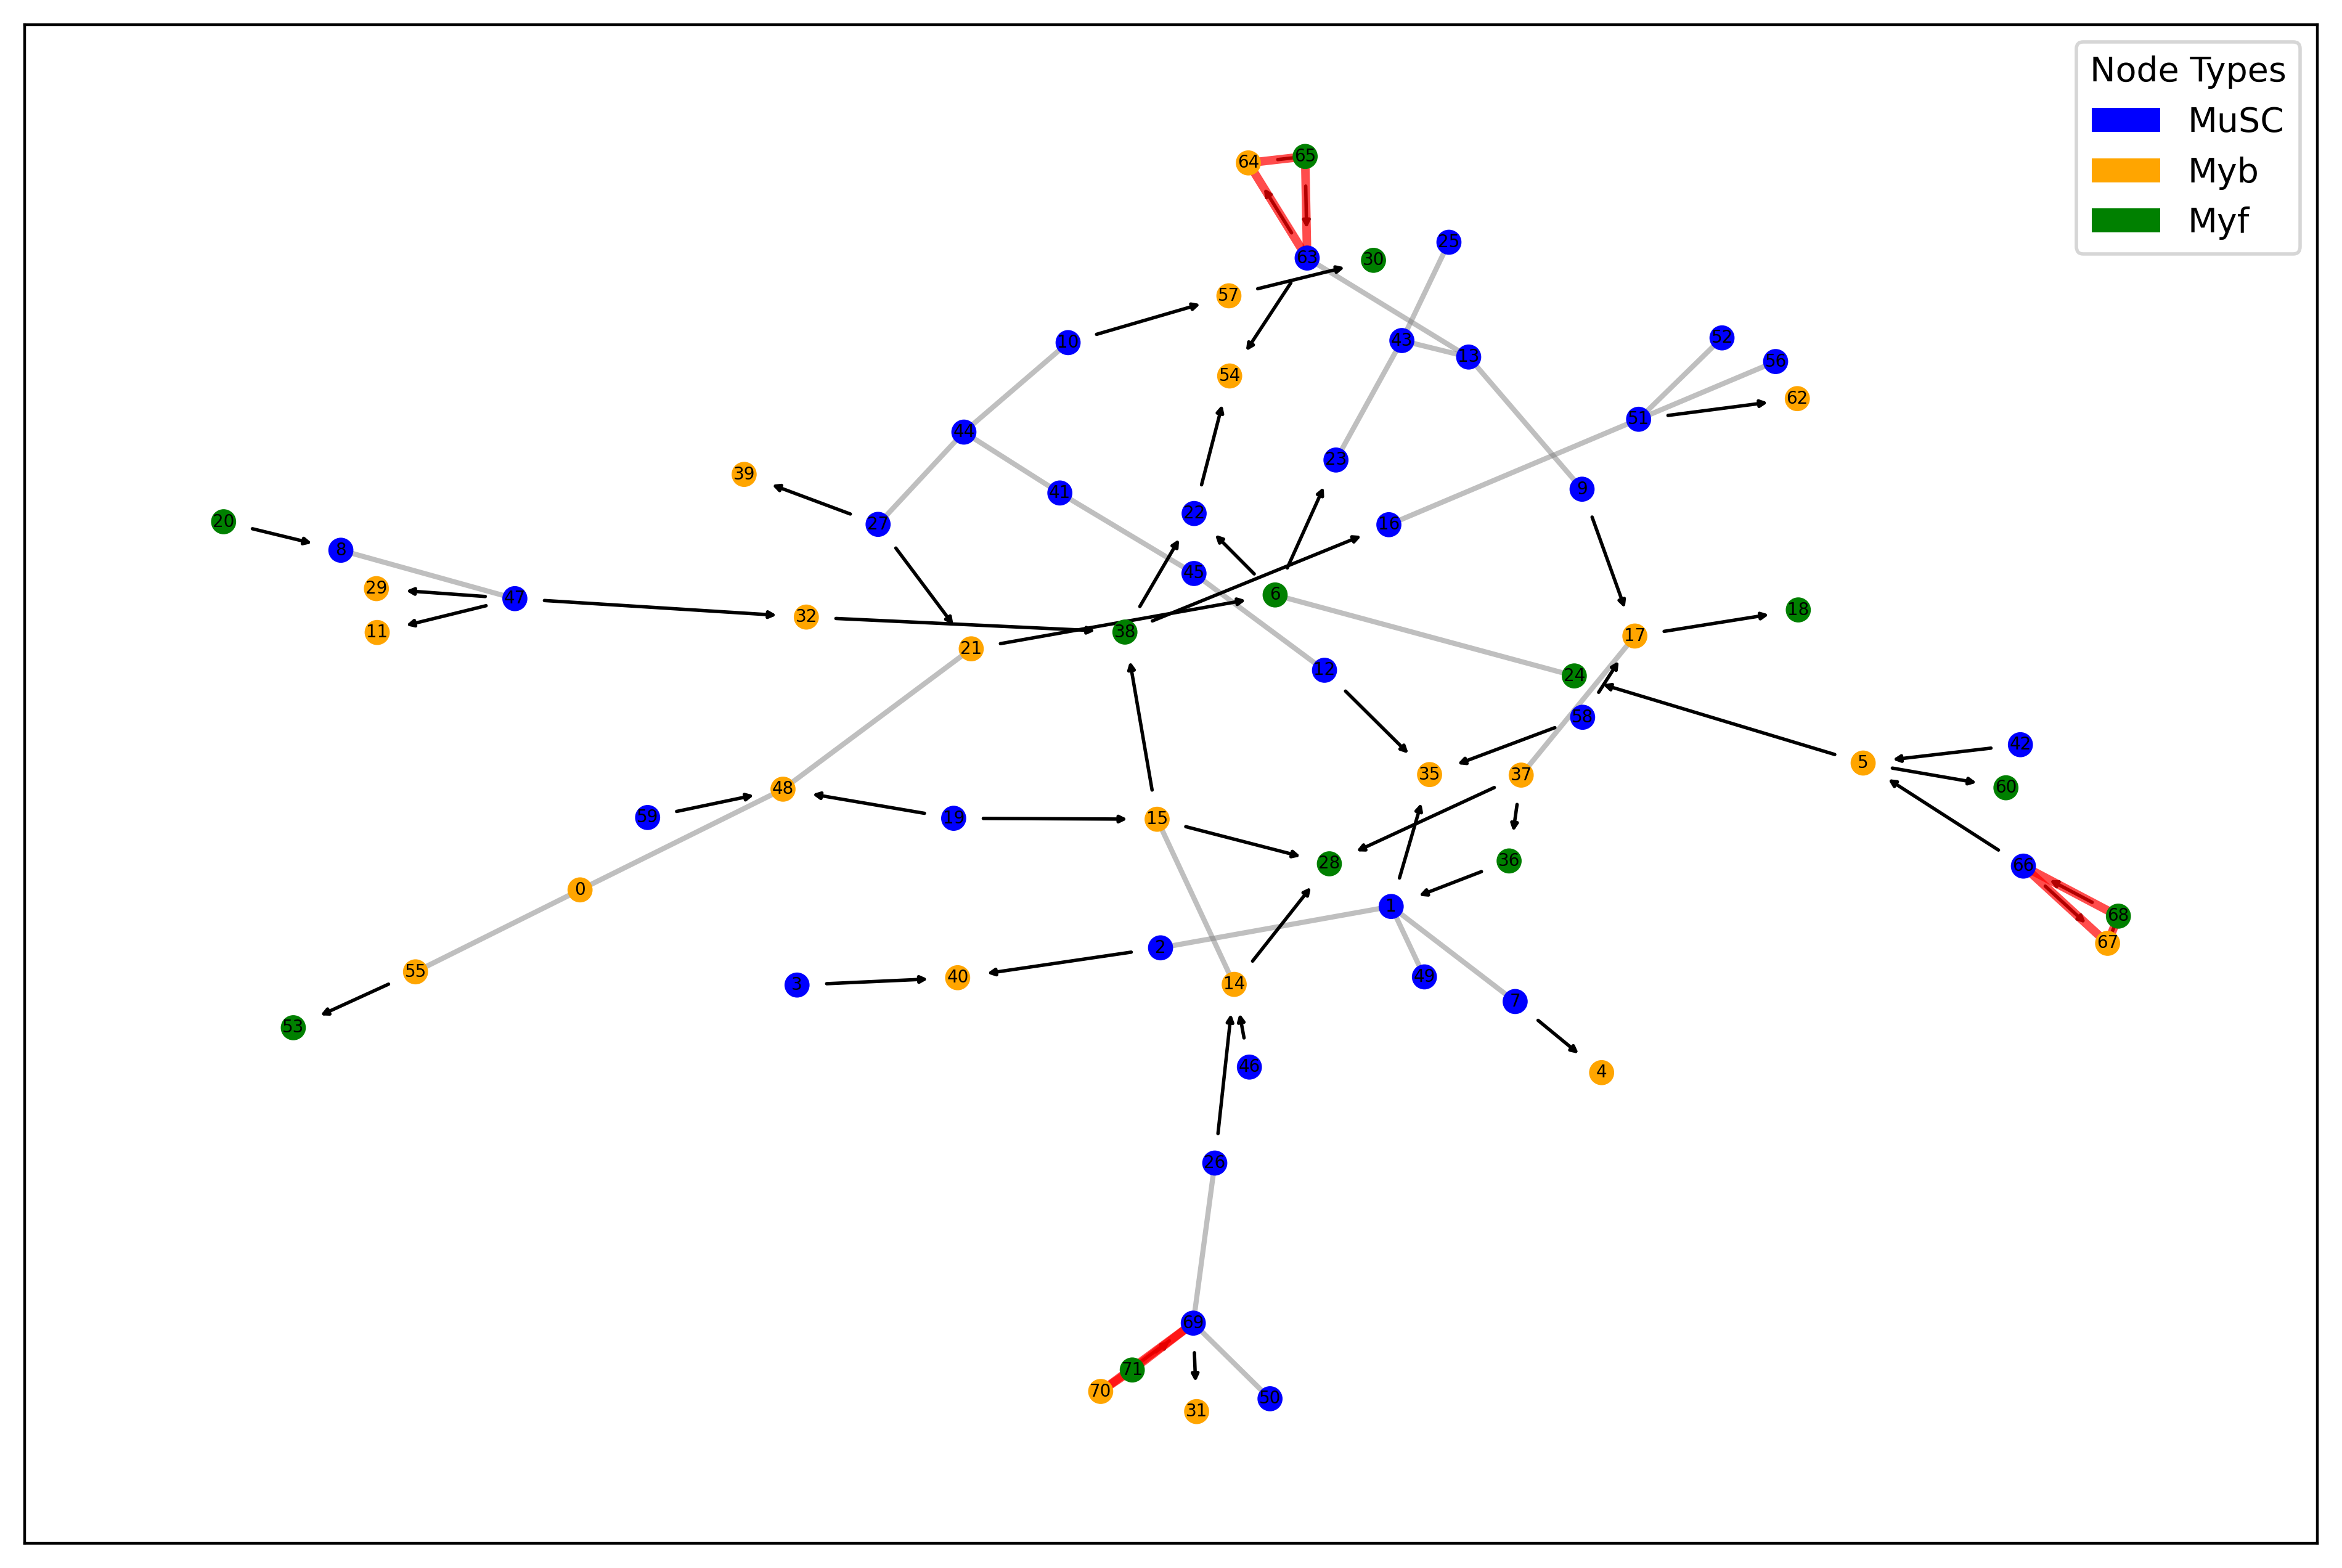

In [11]:
# 测试
if __name__ == "__main__":
    random.seed(0)

    # 1. 生成无向平面图
    n = sample_num_nodes()
    G_undir = generate_random_planar_cell_graph(
        num_nodes=n,
        max_extra_edges=min(n // 10, n // 4),
        seed=42
    )

    # 2. 随机选择若干节点替换为 myogenic 有向环
    num_replace = random.randint(3, min(5, G_undir.number_of_nodes() // 7))
    all_nodes = list(G_undir.nodes())
    nodes_to_replace = random.sample(all_nodes, num_replace)

    print(f"Replacing {num_replace} nodes")
    G = G_undir.copy()  
    for node in nodes_to_replace:
        if node in G:  
            G = replace_node_with_myo_cycle(G, node)
        else:
            print(f"Warning: Node {node} already removed, skipping.")
    # 3. 为无向图添加方向属性
    DG = annotate_edge_directions(G, seed=100)

    # 4. 验证底层无向图仍是平面图
    UG = nx.Graph(DG)  # 忽略方向
    is_planar, _ = nx.check_planarity(UG)
    print(f"Underlying undirected graph is planar: {is_planar}")

    # 5. 可视化
    visual_graph(DG)


In [ ]:
import os
import pickle
import random
import networkx as nx
import itertools
from datetime import datetime

def generate_one_graph(seed=None):
    """
    生成一个符合要求的图
    :param seed: 随机种子（可选）
    :return: networkx.Graph（带 cell_type、directed、direction 等属性）
    """
    if seed is not None:
        random.seed(seed)
        # 注意：networkx 的 random_tree 依赖全局 random

    # 1. 随机节点数（扩大范围增加多样性）
    n = random.randint(15, 80)  # 原为 20~70，现在更广

    # 2. 动态 extra edges
    max_extra = random.randint(5, min(25, n // 2))

    G_undir = generate_random_planar_cell_graph(
        num_nodes=n,
        max_extra_edges=max_extra,
        seed=seed  # 传入 seed 保证可复现（如果需要）
    )

    # 3. 随机选择替换节点数量
    max_replace = max(1, min(8, G_undir.number_of_nodes() // 5))
    num_replace = random.randint(1, max_replace)

    all_nodes = list(G_undir.nodes())
    if len(all_nodes) < num_replace:
        num_replace = len(all_nodes)
    nodes_to_replace = random.sample(all_nodes, num_replace)

    G = G_undir.copy()
    for node in nodes_to_replace:
        if node in G:
            G = replace_node_with_myo_cycle(G, node)

    # 4. 添加方向属性
    DG = annotate_edge_directions(G, seed=seed)

    # 5. 验证平面性（可选，用于调试）
    UG = nx.Graph(DG)
    is_planar, _ = nx.check_planarity(UG)
    if not is_planar:
        print(f"Warning: Non-planar graph generated with seed {seed}")

    return DG

def batch_generate_graphs(
    num_graphs: int = 500,
    save_dir: str = "generated_graphs",
    save_format: str = "pickle"  # or "graphml"
):
    """
    批量生成图并保存
    """
    os.makedirs(save_dir, exist_ok=True)

    for i in range(num_graphs):
        # 使用时间戳 + index 作为种子，确保全局唯一且可复现
        seed = int(datetime.now().timestamp() * 1e6) % (2**32) + i
        # 或者简单用 i 作为 seed（更可控）
        # seed = i

        try:
            graph = generate_one_graph(seed=seed)
            filename = os.path.join(save_dir, f"graph_{i:04d}.{save_format}")

            if save_format == "pickle":
                with open(filename, 'wb') as f:
                    pickle.dump(graph, f)
            else:
                raise ValueError("Unsupported format")

            print(f"Saved {filename} | Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")

        except Exception as e:
            print(f"Failed to generate graph {i}: {e}")
            continue

if __name__ == "__main__":
    # 批量生成 1000 个图
    batch_generate_graphs(
        num_graphs=500,
        save_dir="positive",
        save_format="pickle"  # 推荐 pickle，保留所有属性类型
    )

Generated graph with 58 nodes, 73 edges, 16 extra edges added.
Saved myogenic_graphs\graph_0000.pickle | Nodes: 68, Edges: 88
Generated graph with 36 nodes, 48 edges, 13 extra edges added.
Saved myogenic_graphs\graph_0001.pickle | Nodes: 44, Edges: 60
Generated graph with 25 nodes, 30 edges, 6 extra edges added.
Saved myogenic_graphs\graph_0002.pickle | Nodes: 33, Edges: 42
Generated graph with 24 nodes, 33 edges, 10 extra edges added.
Saved myogenic_graphs\graph_0003.pickle | Nodes: 28, Edges: 39
Generated graph with 26 nodes, 38 edges, 13 extra edges added.
Saved myogenic_graphs\graph_0004.pickle | Nodes: 34, Edges: 50
Generated graph with 69 nodes, 82 edges, 14 extra edges added.
Saved myogenic_graphs\graph_0005.pickle | Nodes: 71, Edges: 85
Generated graph with 53 nodes, 68 edges, 16 extra edges added.
Saved myogenic_graphs\graph_0006.pickle | Nodes: 69, Edges: 92
Generated graph with 34 nodes, 44 edges, 11 extra edges added.
Saved myogenic_graphs\graph_0007.pickle | Nodes: 40, Edg

In [2]:
def no_Mycycle(G, u, v, cell_types):
    """
    检查添加边 (u, v) 是否会形成 {MuSC, Myoblast, Myofiber} 三角形。
    利用：三角形 = u-v 共同邻居 w，且 (u,w), (v,w) 已存在。
    """
    if not G.has_node(u) or not G.has_node(v):
        return False

    # 获取 u 和 v 的共同邻居
    common_neighbors = set(G.neighbors(u)) & set(G.neighbors(v))
    target_set = {'MuSC', 'Myoblast', 'Myofiber'}

    for w in common_neighbors:
        types = {cell_types[u], cell_types[v], cell_types[w]}
        if types == target_set:
            return True
    return False


def has_forbidden_myogenic_triangle(G):
    """
    高效检查图 G 中是否存在 {MuSC, Myoblast, Myofiber} 三角形。
    使用邻居对遍历法，适用于稀疏图（如平面图）。
    """
    target_set = {'MuSC', 'Myoblast', 'Myofiber'}
    try:
        cell_types = nx.get_node_attributes(G, 'cell_type')
    except KeyError:
        raise ValueError("All nodes must have 'cell_type' attribute.")

    for u in G.nodes():
        neighbors = list(G.neighbors(u))
        n = len(neighbors)
        for i in range(n):
            for j in range(i + 1, n):
                v, w = neighbors[i], neighbors[j]
                if G.has_edge(v, w):  # (u, v, w) 构成三角形
                    types = {cell_types[u], cell_types[v], cell_types[w]}
                    if types == target_set:
                        return True, [u, v, w]
    return False, None


def generate_no_myogenic_cycle(
    num_nodes: int,
    max_extra_edges: int = 15,
    seed: int = None
):
    """
    生成一个连通、平面、无 {MuSC, Myoblast, Myofiber} 三角形的随机细胞图。
    
    :param num_nodes: 节点数（建议 15~80）
    :param max_extra_edges: 在树基础上最多添加的边数
    :param seed: 随机种子（用于可复现性）
    :return: networkx.Graph，每个节点含 'cell_type' 属性，且无 forbidden 三角形
    """
    if seed is not None:
        random.seed(seed)

    # Step 1: 生成随机树（连通、无环、平面）
    G = nx.random_tree(num_nodes, seed=seed)

    # Step 2: 分配细胞类型，并缓存到字典（加速后续查询）
    type_weights = [0.5, 0.3, 0.2]
    cell_assignments = random.choices(CELL_TYPES, weights=type_weights, k=num_nodes)
    cell_types = {}
    for i, ct in enumerate(cell_assignments):
        G.nodes[i]['cell_type'] = ct
        cell_types[i] = ct

    # Step 3: 获取所有非边并打乱
    all_pairs = itertools.combinations(G.nodes(), 2)
    non_edges = [e for e in all_pairs if not G.has_edge(*e)]
    random.shuffle(non_edges)

    # Step 4: 尝试添加边，同时满足：
    #   (a) 不形成 forbidden 三角形
    #   (b) 保持平面性
    added = 0
    for u, v in non_edges:
        if added >= max_extra_edges:
            break

        # 检查是否会形成 forbidden 三角形
        if no_Mycycle(G, u, v, cell_types):
            continue

        # 检查平面性（临时加边测试）
        G_test = G.copy()
        G_test.add_edge(u, v)
        if nx.check_planarity(G_test)[0]:
            G.add_edge(u, v)
            added += 1

    # 可选：最终验证（调试用，生产可关闭）
    has_forbidden, tri = has_forbidden_myogenic_triangle(G)
    if has_forbidden:
        raise RuntimeError(f"Unexpected forbidden triangle found: {tri}")

    is_planar, _ = nx.check_planarity(G)
    if not is_planar:
        raise RuntimeError("Graph is not planar!")

    print(f"[No-cycle graph] Nodes: {num_nodes}, Edges: {G.number_of_edges()}, "
          f"Extra edges added: {added}")
    return G

In [ ]:
# --- 批量生成主函数 ---
def batch_generate_no_cycle_graphs(
    num_graphs: int = 1000,
    save_dir: str = "no_myo_cycle_graphs",
    save_format: str = "pkl",  # or "pickle"
    min_nodes: int = 15,
    max_nodes: int = 80,
):
    os.makedirs(save_dir, exist_ok=True)
    
    for i in range(num_graphs):
        # 使用 i 作为 seed，确保可复现且每图不同
        seed = i
        
        # 随机节点数
        n = random.randint(15, 80)  # 原为 20~70，现在更广
        num_nodes = random.randint(min_nodes, max_nodes)
        max_extra = random.randint(5, min(25, n // 2))
        
        try:
            G = generate_no_myogenic_cycle(
                num_nodes=num_nodes,
                max_extra_edges=max_extra,
                seed=seed
            )
            
            filename = os.path.join(save_dir, f"graph_{i:04d}.{save_format}")
            with open(filename, 'wb') as f:
                pickle.dump(G, f)
                
            print(f"[{i+1}/{num_graphs}] Saved {filename} | "
                  f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
                  
        except Exception as e:
            print(f"[{i+1}/{num_graphs}] Failed to generate graph {i}: {e}")
            continue

if __name__ == "__main__":
    batch_generate_no_cycle_graphs(
        num_graphs=100,
        save_dir="negative_samples",  # 负样本目录
        save_format="pickle"
    )

[No-cycle graph] Nodes: 45, Edges: 59, Extra edges added: 15
[1/1000] Saved negative_samples\graph_0000.pickle | Nodes: 45, Edges: 59
[No-cycle graph] Nodes: 67, Edges: 85, Extra edges added: 19
[2/1000] Saved negative_samples\graph_0001.pickle | Nodes: 67, Edges: 85
[No-cycle graph] Nodes: 44, Edges: 64, Extra edges added: 21
[3/1000] Saved negative_samples\graph_0002.pickle | Nodes: 44, Edges: 64
[No-cycle graph] Nodes: 65, Edges: 81, Extra edges added: 17
[4/1000] Saved negative_samples\graph_0003.pickle | Nodes: 65, Edges: 81
[No-cycle graph] Nodes: 23, Edges: 38, Extra edges added: 16
[5/1000] Saved negative_samples\graph_0004.pickle | Nodes: 23, Edges: 38
[No-cycle graph] Nodes: 35, Edges: 49, Extra edges added: 15
[6/1000] Saved negative_samples\graph_0005.pickle | Nodes: 35, Edges: 49
[No-cycle graph] Nodes: 38, Edges: 54, Extra edges added: 17
[7/1000] Saved negative_samples\graph_0006.pickle | Nodes: 38, Edges: 54
[No-cycle graph] Nodes: 30, Edges: 34, Extra edges added: 5
[8